In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('superstore.csv', encoding='latin1')


print(df.shape)
print(df.head())
print(df.columns)

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [15]:
print("Missing Values:")
print(df.isnull().sum())


print("\nData Types:")
print(df.dtypes)


df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("\nCleaning Done!")
print(df.shape)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Cleaning Done!
(999

In [16]:



category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Sales by Category:")
print(category_sales)


yearly_sales = df.groupby('Year')['Sales'].sum()
print("\nSales by Year:")
print(yearly_sales)


top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 States:")
print(top_states)


category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Category:")
print(category_profit)

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Sales by Year:
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Top 10 States:
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


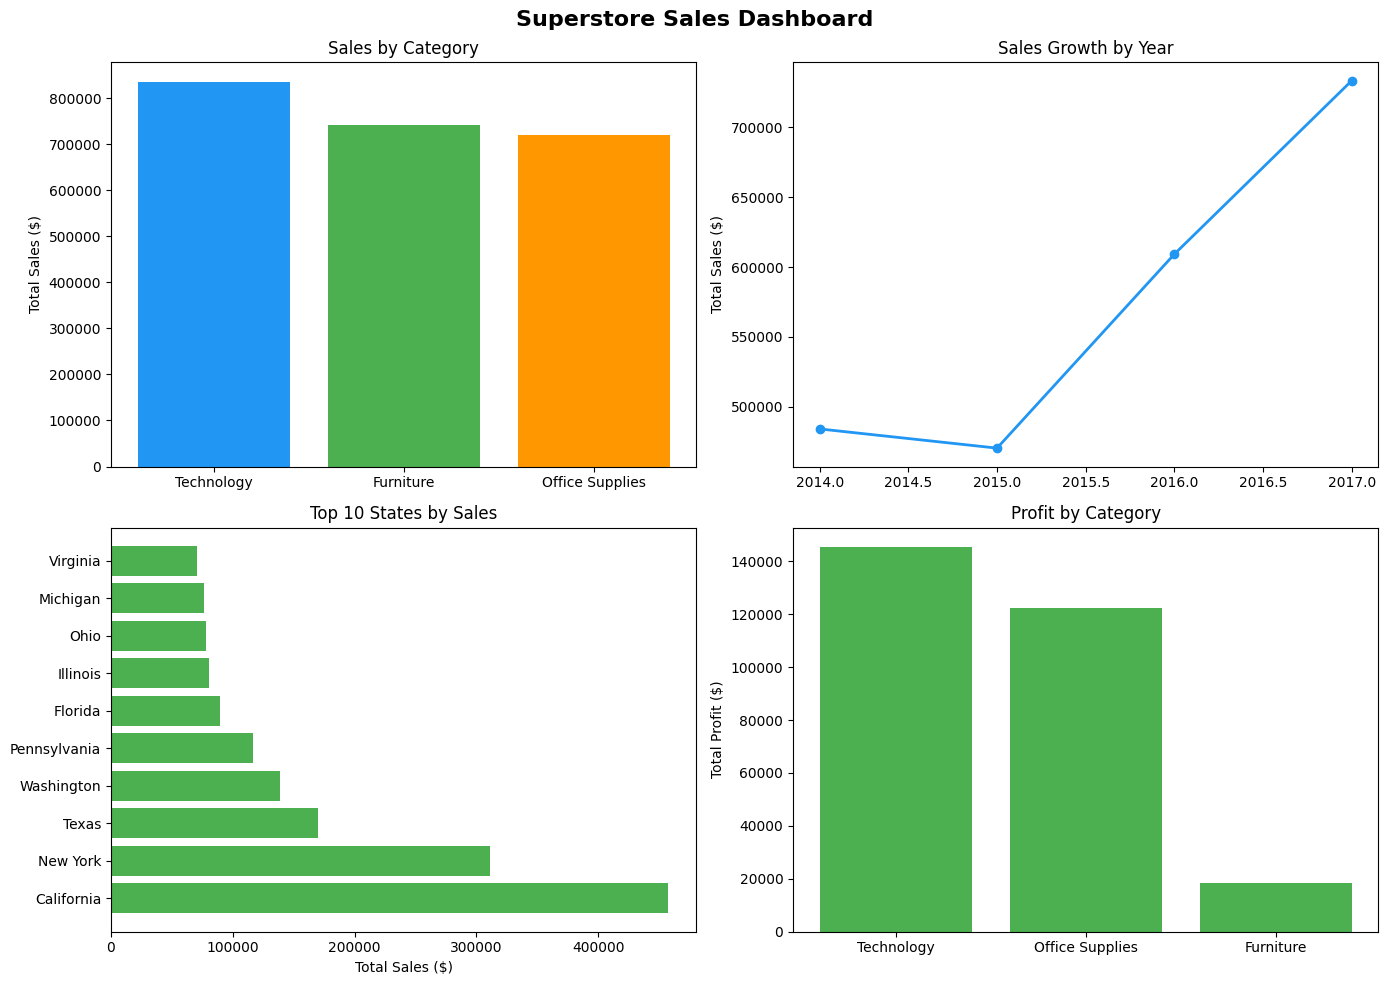

Dashboard saved!


In [17]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Dashboard', fontsize=16, fontweight='bold')


axes[0, 0].bar(category_sales.index, category_sales.values, 
               color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0, 0].set_title('Sales by Category')
axes[0, 0].set_ylabel('Total Sales ($)')


axes[0, 1].plot(yearly_sales.index, yearly_sales.values, 
                marker='o', color='#2196F3', linewidth=2)
axes[0, 1].set_title('Sales Growth by Year')
axes[0, 1].set_ylabel('Total Sales ($)')


axes[1, 0].barh(top_states.index, top_states.values, color='#4CAF50')
axes[1, 0].set_title('Top 10 States by Sales')
axes[1, 0].set_xlabel('Total Sales ($)')


colors = ['#4CAF50' if x > 0 else '#F44336' for x in category_profit.values]
axes[1, 1].bar(category_profit.index, category_profit.values, color=colors)
axes[1, 1].set_title('Profit by Category')
axes[1, 1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [18]:

import sqlite3


conn = sqlite3.connect('superstore.db')
df.to_sql('sales', conn, if_exists='replace', index=False)


query1 = """
SELECT "Product Name", 
       ROUND(SUM(Sales), 2) as Total_Sales,
       ROUND(SUM(Profit), 2) as Total_Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 5
"""


query2 = """
SELECT Region,
       ROUND(SUM(Sales), 2) as Total_Sales,
       ROUND(AVG(Discount), 2) as Avg_Discount,
       ROUND(SUM(Profit), 2) as Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""

print("Top 5 Products:")
print(pd.read_sql_query(query1, conn))
print("\nSales by Region:")
print(pd.read_sql_query(query2, conn))

conn.close()

Top 5 Products:
                                        Product Name  Total_Sales  \
0              Canon imageCLASS 2200 Advanced Copier     61599.82   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...     27453.38   
2  Cisco TelePresence System EX90 Videoconferenci...     22638.48   
3       HON 5400 Series Task Chairs for Big and Tall     21870.58   
4         GBC DocuBind TL300 Electric Binding System     19823.48   

   Total_Profit  
0      25199.93  
1       7753.04  
2      -1811.08  
3          0.00  
4       2233.51  

Sales by Region:
    Region  Total_Sales  Avg_Discount  Total_Profit
0     West    725457.82          0.11     108418.45
1     East    678781.24          0.15      91522.78
2  Central    501239.89          0.24      39706.36
3    South    391721.91          0.15      46749.43
